In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data
from PIL import Image

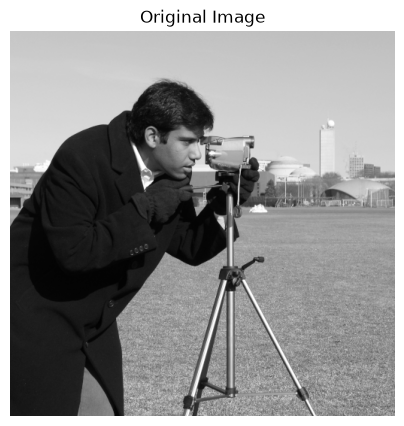

In [2]:
original_image = data.camera()

plt.figure(figsize=(5,5))
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [3]:
def sample_image(image, factor):
    height, width = image.shape[:2]
    sampled_image = cv2.resize(
        image,
        (width // factor, height // factor),
        interpolation=cv2.INTER_NEAREST
    )
    return sampled_image


def quantize_image(image, levels):
    step = 256 // levels
    quantized_image = np.floor(image / step) * step
    quantized_image = np.clip(quantized_image, 0, 255)
    return quantized_image.astype(np.uint8)

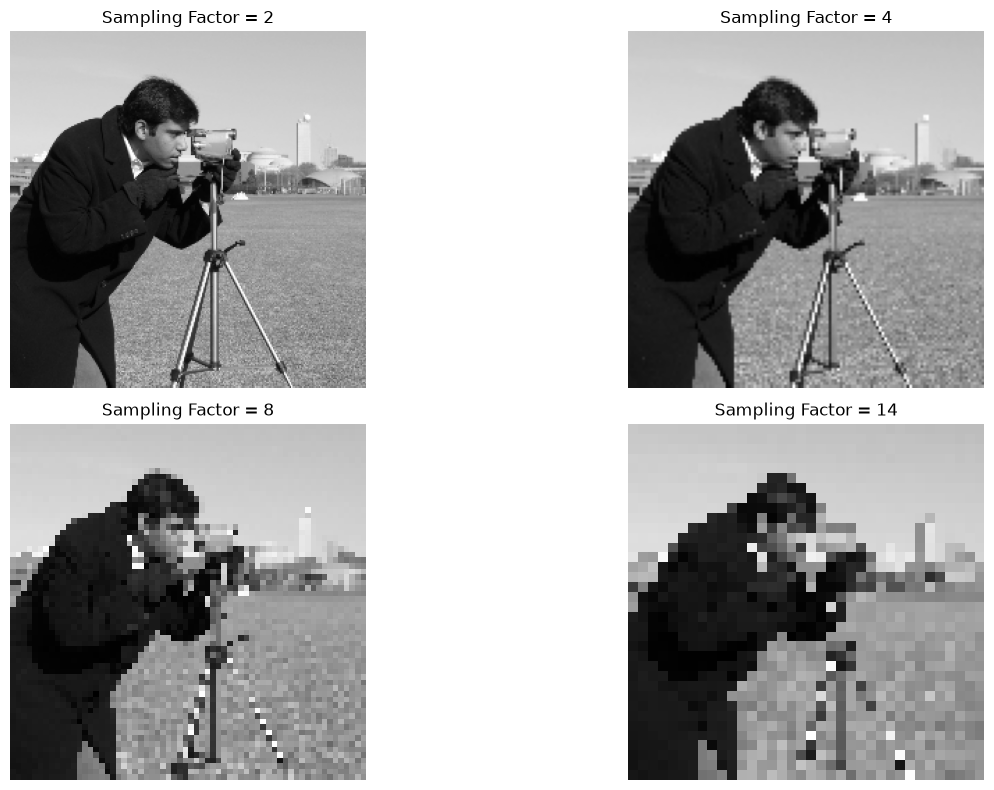

In [4]:
sampling_factors = [2, 4, 8, 14]

plt.figure(figsize=(15, 8))

for i, factor in enumerate(sampling_factors):
    sampled = sample_image(original_image, factor)

    plt.subplot(2, 2, i + 1)
    plt.imshow(sampled, cmap='gray')
    plt.title(f'Sampling Factor = {factor}')
    plt.axis('off')

plt.tight_layout()
plt.show()

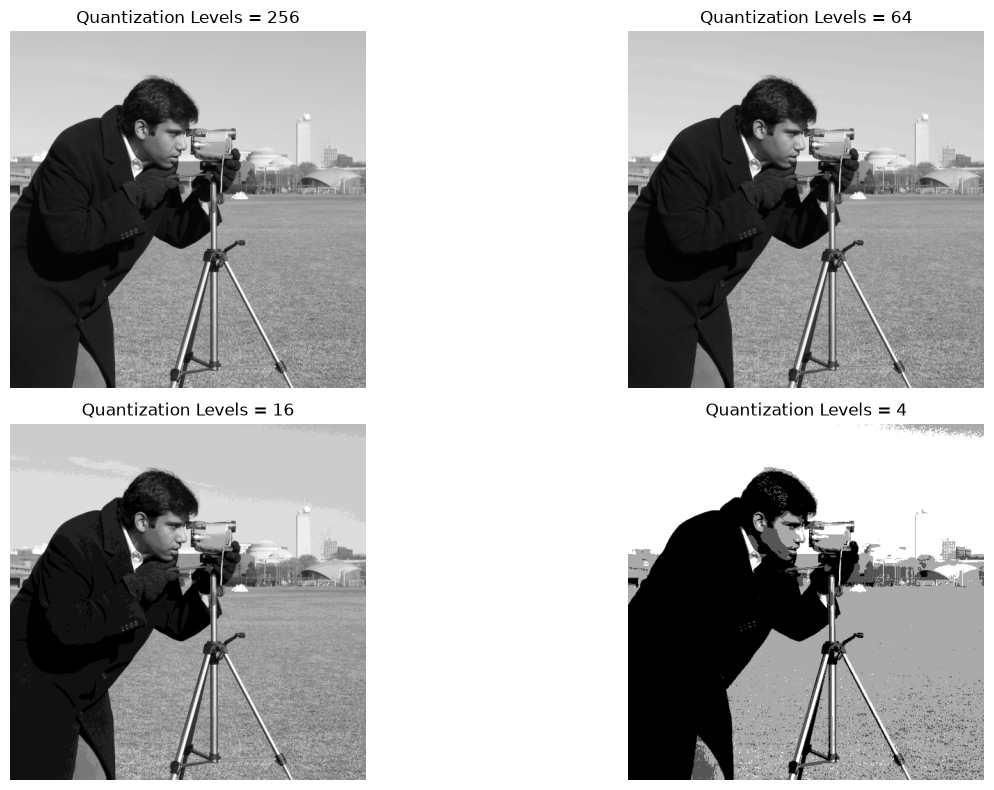

In [5]:
quantization_levels = [256, 64, 16, 4]

plt.figure(figsize=(15, 8))

for i, levels in enumerate(quantization_levels):
    quantized = quantize_image(original_image, levels)

    plt.subplot(2, 2, i + 1)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'Quantization Levels = {levels}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
new_size = (400, 400)

img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3).astype(np.uint8) * 255
im4arr = np.asarray(img4).astype(np.uint8) * 255

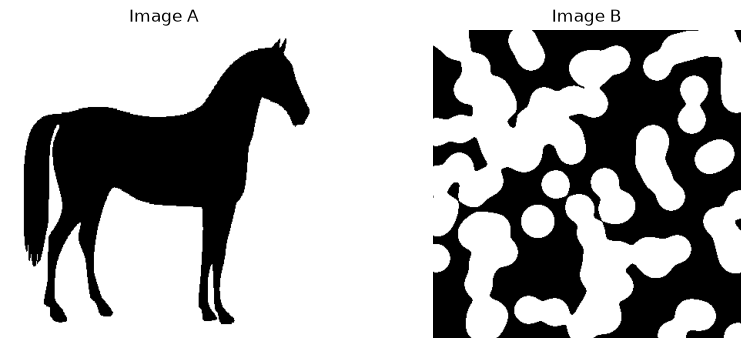

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im3arr, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(im4arr, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.show()

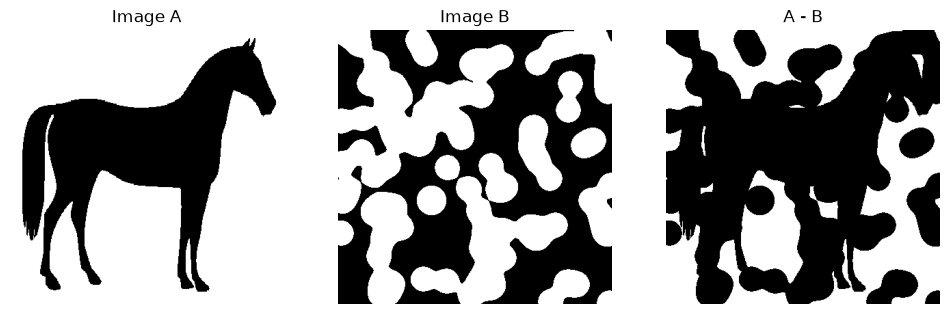

In [8]:
subtracted = cv2.subtract(im3arr, im4arr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(im3arr, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(im4arr, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(subtracted, cmap='gray')
plt.title('A - B')
plt.axis('off')

plt.show()

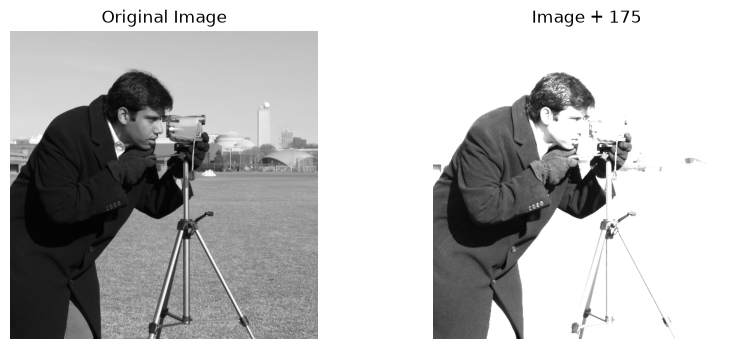

In [9]:
image = data.camera()

added_image = cv2.add(image, 175)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(added_image, cmap='gray')
plt.title('Image + 175')
plt.axis('off')

plt.show()

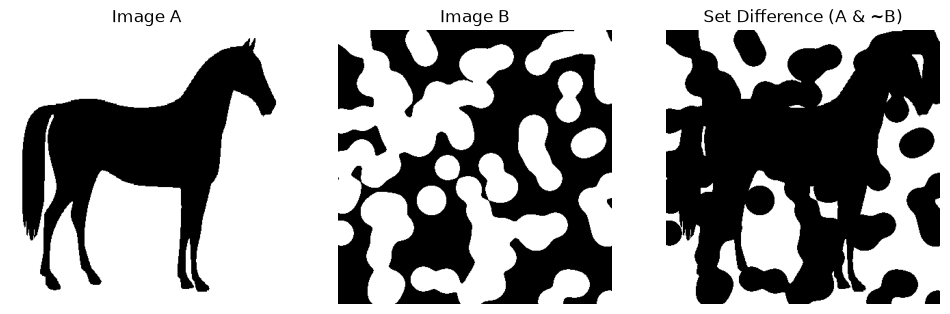

In [10]:
set_difference = im3arr & ~im4arr

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(im3arr, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(im4arr, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(set_difference, cmap='gray')
plt.title('Set Difference (A & ~B)')
plt.axis('off')

plt.show()

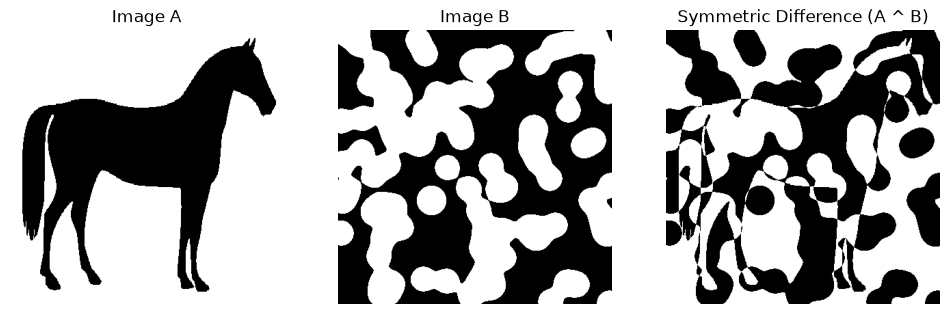

In [11]:
symmetric_difference = im3arr ^ im4arr

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(im3arr, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(im4arr, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(symmetric_difference, cmap='gray')
plt.title('Symmetric Difference (A ^ B)')
plt.axis('off')

plt.show()

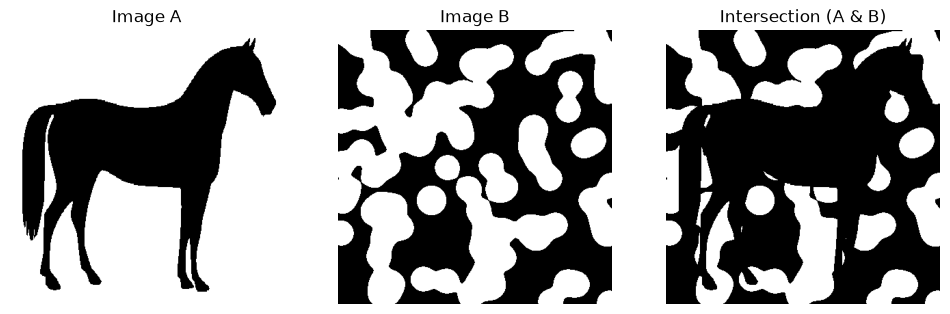

In [12]:
intersection = im3arr & im4arr

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(im3arr, cmap='gray')
plt.title('Image A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(im4arr, cmap='gray')
plt.title('Image B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(intersection, cmap='gray')
plt.title('Intersection (A & B)')
plt.axis('off')

plt.show()